In [ ]:
print("Hello, Guys!")

In [ ]:
print(2+3, 2*3, 2**3)

In [ ]:
s = "hi"
print(s.upper(), len(s))

In [ ]:
dir(str)
help(str.upper)

In [ ]:
lst = [1, 2, 3]
lst.append(4)
lst.remove(2)
print(lst)

In [ ]:
t = (1, 2, 3)
print(t[0], len(t))

In [ ]:
s1 = {1, 2, 3}
s2 = {2, 3, 4}
print(s1 & s2, s1 - s2)

In [ ]:
d = {"name": "Ali", "age": 20}
print(d["name"])

In [ ]:
def main():
    print("Script running")

main()

In [ ]:
if True:
    print("Inside block")
print("Outside block")

In [ ]:
def foo():
    x = 1     # I used 4 spaces, not tabs
    return x

In [1]:
def greet(name="World"):
    return f"Hello, {name}!"

print(greet("Abdul"))

Hello, Abdul!


In [ ]:
class Person:
    def __init__(self, name):   # __init__ is a special function that runs automatically
        self.name = name        # self refers to the object

p = Person("Ali")
print(p.name)

In [ ]:
p = Person("Ali")
print(p.greet())

In [ ]:
class Counter:
    total = 0        # static variable

    def __init__(self):
        self.count = 0  # instance variable
        Counter.total += 1

The Fractal code

Saved: newton_fractal.png


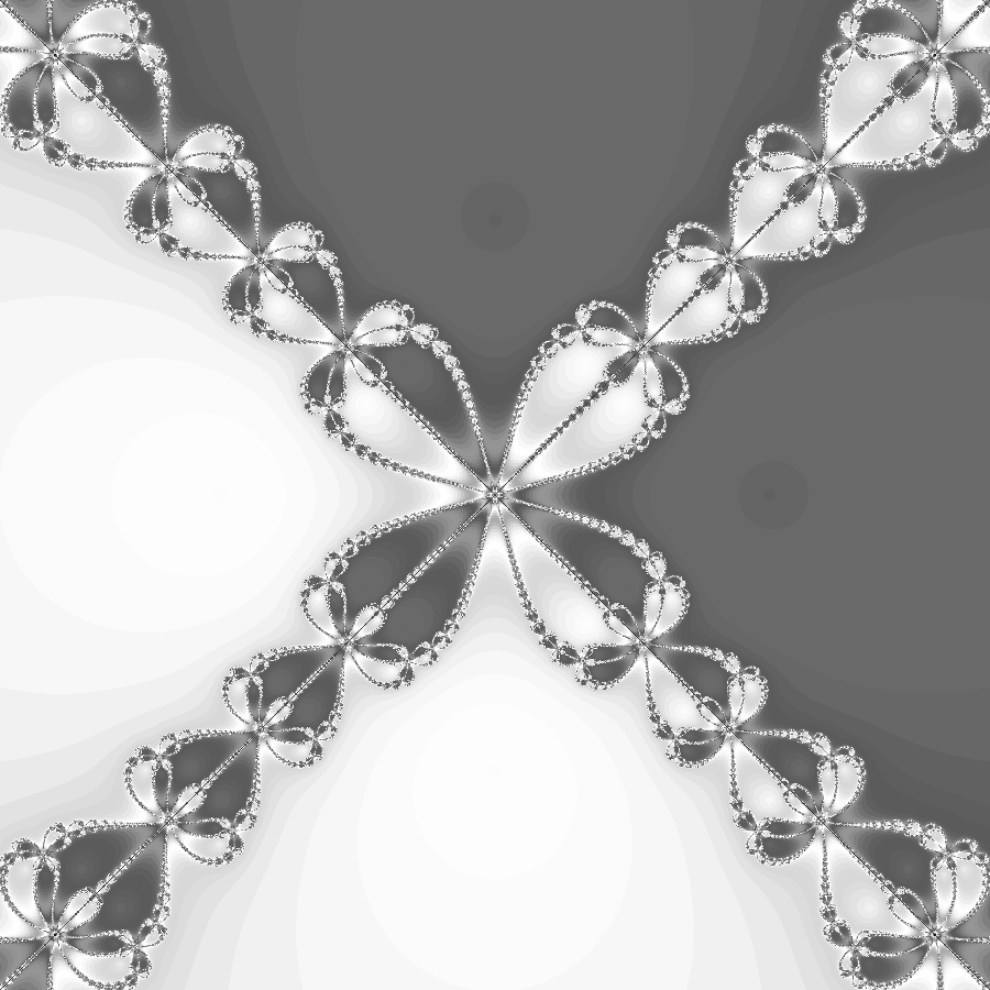

In [4]:
"""
Newton Fractal — Monochrome Ray Bloom
========================================
This recreates the look in the reference image: a Newton fractal for a
complex polynomial, rendered in grayscale. Newton fractals get their
"ray/petal" look from Newton's method root-finding: from every point in
the complex plane we iterate

    z = z - f(z)/f'(z)

and color the pixel by (a) which root it converges to and (b) how many
iterations it took. Basins of attraction interleave into long curved
"rays," and the boundaries between them are fractal (infinitely detailed,
self-similar) - that's the lacy black/white coastline you see around the
center.

Run:
    python newton_fractal.py
"""

import numpy as np
import matplotlib.pyplot as plt


# ----------------------------------------------------------------------
# POLYNOMIAL + DERIVATIVE
# ----------------------------------------------------------------------
# z^4 - 1 = 0 has 4 roots (the 4th roots of unity): 1, -1, i, -i.
# This is the classic polynomial used for the "flower/ray" Newton fractal.

def f(z):
    return z**4 - 1

def fprime(z):
    return 4 * z**3


# ----------------------------------------------------------------------
# NEWTON FRACTAL FIELD
# ----------------------------------------------------------------------

def newton_fractal(xmin, xmax, ymin, ymax, width, height, max_iter=60, tol=1e-6):
    x = np.linspace(xmin, xmax, width)
    y = np.linspace(ymin, ymax, height)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y

    iters = np.zeros(Z.shape, dtype=float)
    active = np.ones(Z.shape, dtype=bool)

    for i in range(max_iter):
        with np.errstate(divide="ignore", invalid="ignore"):
            deriv = fprime(Z)
            deriv[deriv == 0] = 1e-12
            Z_new = Z - f(Z) / deriv

        step = np.abs(Z_new - Z)
        Z = np.where(active, Z_new, Z)

        newly_converged = active & (step < tol)
        iters[newly_converged] = i
        active &= ~newly_converged

        if not active.any():
            break

    iters[active] = max_iter  # points that never converged

    roots = [1, -1, 1j, -1j]
    dists = np.array([np.abs(Z - r) for r in roots])
    root_id = np.argmin(dists, axis=0)          # which root each pixel landed on
    dist = np.min(dists, axis=0)

    return iters, dist, root_id


# ----------------------------------------------------------------------
# GRAYSCALE "RAY BLOOM" SHADING
# ----------------------------------------------------------------------

def shade(iters, dist, root_id, max_iter):
    """
    Combine root id + iteration count + distance-to-root into a
    monochrome field. Alternating roots get alternating brightness
    (this produces the black vs. white "petal" basins in the reference
    image), fine boundary detail creates the lacy fractal coastline,
    and a central glow burst plus radiating rings reproduce the bright
    starburst around the origin.
    """
    norm_iters = np.clip(iters / max_iter, 0, 1)

    # basins alternate near-black / near-white depending on root
    basin_tone = np.array([0.03, 0.97, 0.03, 0.97])[root_id]

    # pixels near a basin boundary took many iterations -> pull them
    # toward the *opposite* tone in fine oscillating bands, producing
    # the lacy interleaved black/white coastline
    boundary_strength = np.clip(norm_iters * 1.4, 0, 1)
    bands = np.sin(norm_iters * np.pi * 10)
    field = basin_tone * (1 - boundary_strength) + (0.5 + 0.5 * bands) * boundary_strength

    # radiating rings + soft glow bursting out from each root
    rings = 0.5 + 0.5 * np.cos(dist * 11.0)
    glow = np.exp(-dist * 1.3)
    field = field * (1 - 0.55 * glow) + rings * (0.55 * glow)

    # extra bright core at the very center (origin), like the reference
    center_glow = np.exp(-dist_from_center(dist.shape) * 3.0) if False else 0
    field = (field - field.min()) / (field.max() - field.min())
    return field


def dist_from_center(shape):
    h, w = shape
    yy, xx = np.mgrid[0:h, 0:w]
    cy, cx = h / 2, w / 2
    return np.sqrt(((xx - cx) / w) ** 2 + ((yy - cy) / h) ** 2)


def render(save_path="newton_fractal.png", width=900, height=900, max_iter=70):
    span = 1.8
    iters, dist, root_id = newton_fractal(-span, span, -span, span, width, height, max_iter)
    field = shade(iters, dist, root_id, max_iter)

    fig, ax = plt.subplots(figsize=(9, 9), dpi=110)
    ax.imshow(field, cmap="gray", origin="lower", interpolation="bilinear")
    ax.axis("off")
    plt.tight_layout(pad=0)
    plt.savefig(save_path, facecolor="black", bbox_inches="tight", pad_inches=0)
    plt.close(fig)
    print(f"Saved: {save_path}")

from IPython.display import Image, display

if __name__ == "__main__":
    render()
    display(Image(filename="newton_fractal.png"))